#AI Capstone Project Prep - AIGC-5005-RNA
#Midterm Project

#Name: Kash Kannaiti, Fadi
#Student # N01232536

In [23]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AIGC5005/risk-train.txt', sep='\t')
print(df.shape)  # Should print (30000, 44)
# Note: If the file uses a different separator (comma, semicolon), change sep='\t' to sep=',' or ';'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(30000, 44)


# 1. Exploratory Data Analysis

(30000, 44)
ORDER_ID               int64
CLASS                 object
B_EMAIL               object
B_TELEFON             object
B_BIRTHDATE           object
FLAG_LRIDENTISCH      object
FLAG_NEWSLETTER       object
Z_METHODE             object
Z_CARD_ART            object
Z_CARD_VALID         float64
Z_LAST_NAME           object
VALUE_ORDER          float64
WEEKDAY_ORDER         object
TIME_ORDER            object
AMOUNT_ORDER           int64
ANUMMER_01             int64
ANUMMER_02            object
ANUMMER_03            object
ANUMMER_04            object
ANUMMER_05            object
ANUMMER_06            object
ANUMMER_07            object
ANUMMER_08            object
ANUMMER_09            object
ANUMMER_10            object
CHK_LADR              object
CHK_RADR              object
CHK_KTO               object
CHK_CARD              object
CHK_COOKIE            object
CHK_IP                object
FAIL_LPLZ             object
FAIL_LORT             object
FAIL_LPLZORTMATCH     object
FA

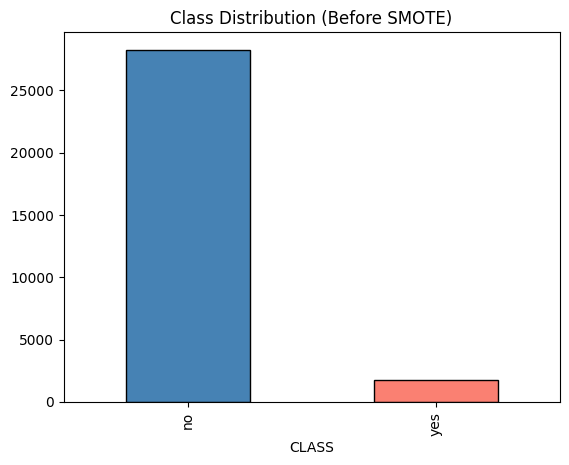

Series([], dtype: int64)


,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25032.612933,6.680567,43.968058,1.442200,331860.254033,8.577900,0.606700,29.875652
std,14422.306098,3.468332,35.709431,0.921496,147310.846584,3.863448,0.765616,57.382732
min,1.000000,1.200500,5.200000,1.000000,100061.000000,1.000000,0.000000,0.000000
25%,12518.750000,3.200700,17.990000,1.000000,204159.000000,6.000000,0.000000,0.000000
50%,25095.500000,6.200700,34.500000,1.000000,401241.000000,9.000000,0.000000,0.000000
75%,37520.250000,10.200500,57.800000,2.000000,407703.000000,11.000000,1.000000,38.470000
max,50000.000000,12.200700,361.200000,9.000000,609725.000000,24.000000,6.000000,1047.800000


In [24]:
# Cell 1 — Basic shape and data types:
print(df.shape)         # rows and columns
print(df.dtypes)        # data type of each column
df.head(5)              # first 5 rows
# Cell 2 — Class distribution (target variable):
import matplotlib.pyplot as plt
df['CLASS'].value_counts().plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Class Distribution (Before SMOTE)')
plt.show()  # Save this chart for your report!
# Cell 3 — Missing values:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])  # Only show columns with missing values
# Cell 4 — Summary statistics:
df.describe()  # Stats for numeric columns

# 2. Data Preprocessing

In [25]:
# 2a — Drop irrelevant columns:
df = df.drop(columns=['ORDER_ID'])  # Not a predictor
# Also drop any columns with > 60% missing values after inspecting EDA output

# 2b — Encode target variable:
df['CLASS'] = df['CLASS'].map({'yes': 1, 'no': 0})

# 2c — Handle missing values:
# Binary yes/no columns — fill missing with mode (most common value)
binary_cols = ['B_EMAIL','B_TELEFON','FLAG_LRIDENTISCH','FLAG_NEWSLETTER',
               'CHK_LADR','CHK_RADR','CHK_KTO','CHK_CARD','CHK_COOKIE','CHK_IP',
               'FAIL_LPLZ','FAIL_LORT','FAIL_LPLZORTMATCH','FAIL_RPLZ','FAIL_RORT',
               'FAIL_RPLZORTMATCH','NEUKUNDE','Z_LAST_NAME']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
# History columns — fill with 0 (no prior history)
df[['AMOUNT_ORDER_PRE','VALUE_ORDER_PRE','MAHN_AKT','MAHN_HOECHST']] = \
    df[['AMOUNT_ORDER_PRE','VALUE_ORDER_PRE','MAHN_AKT','MAHN_HOECHST']].fillna(0)
# Continuous columns — fill with median
df['SESSION_TIME'] = df['SESSION_TIME'].fillna(df['SESSION_TIME'].median())

# 2d — Encode binary yes/no columns:
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes':1,'no':0,'j':1,'n':0}).fillna(0).astype(int)

# 2e — One-Hot Encode categorical columns:
cat_cols = ['Z_METHODE','Z_CARD_ART','WEEKDAY_ORDER']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 2f — Handle date columns:
# Drop date columns or convert to numeric (days since epoch)
df = df.drop(columns=['B_BIRTHDATE','Z_CARD_VALID','DATE_LORDER'], errors='ignore')

# 2g — Drop remaining non-numeric columns:
df = df.select_dtypes(include=['number'])  # Keep only numeric columns
print('Final shape:', df.shape)  # Confirm no non-numeric columns remain

# 2h — Train-test split:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['CLASS'])
y = df['CLASS']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# 2i — Apply SMOTE to training data only:
!pip install imbalanced-learn  # Run this once at the top of the notebook
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('After SMOTE:', y_train_sm.value_counts())  # Should be roughly equal

Final shape: (30000, 25)
After SMOTE: CLASS
0    22603
1    22603
Name: count, dtype: int64


# 3. Model Development

In [30]:
#3a — Import all classifiers:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#3b — Baseline comparison across all models:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1')
    print(f'{name}: F1={scores.mean():.3f} (+/- {scores.std():.3f})')

#3c — Hyperparameter tuning for best model (example: Random Forest):
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                    param_grid, cv=cv, scoring='f1', n_jobs=2, verbose=1)
grid.fit(X_train_sm, y_train_sm)
print('Best params:', grid.best_params_)
# 3d — Train final model with best parameters:
final_model = grid.best_estimator_
final_model = grid.best_estimator_  # Best model, already fitted by GridSearchCV


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression: F1=0.809 (+/- 0.008)
Decision Tree: F1=0.895 (+/- 0.004)
Random Forest: F1=0.912 (+/- 0.003)
Gradient Boosting: F1=0.840 (+/- 0.003)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


# 4. Results and Evaluation

=== TRAINING SET ===
              precision    recall  f1-score   support

          no       1.00      0.99      1.00     22603
         yes       0.99      1.00      1.00     22603

    accuracy                           1.00     45206
   macro avg       1.00      1.00      1.00     45206
weighted avg       1.00      1.00      1.00     45206

=== TEST SET ===
              precision    recall  f1-score   support

          no       0.95      0.92      0.94      5651
         yes       0.14      0.21      0.17       349

    accuracy                           0.88      6000
   macro avg       0.55      0.57      0.55      6000
weighted avg       0.90      0.88      0.89      6000



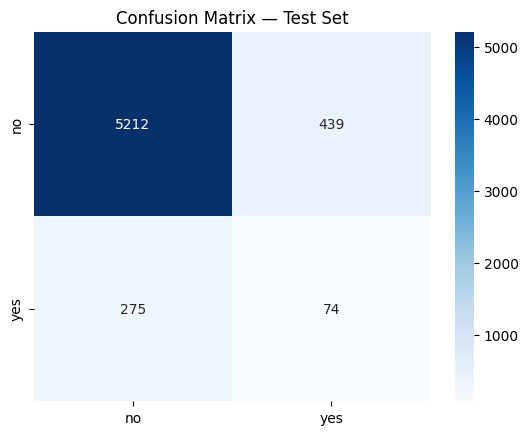

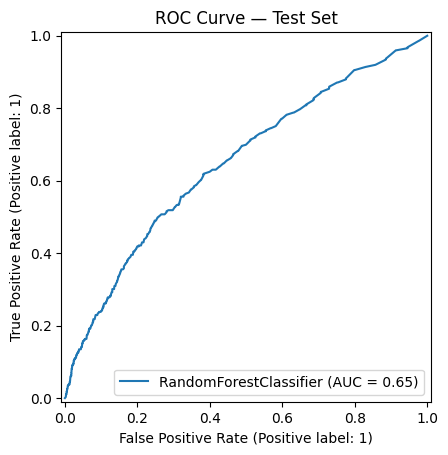

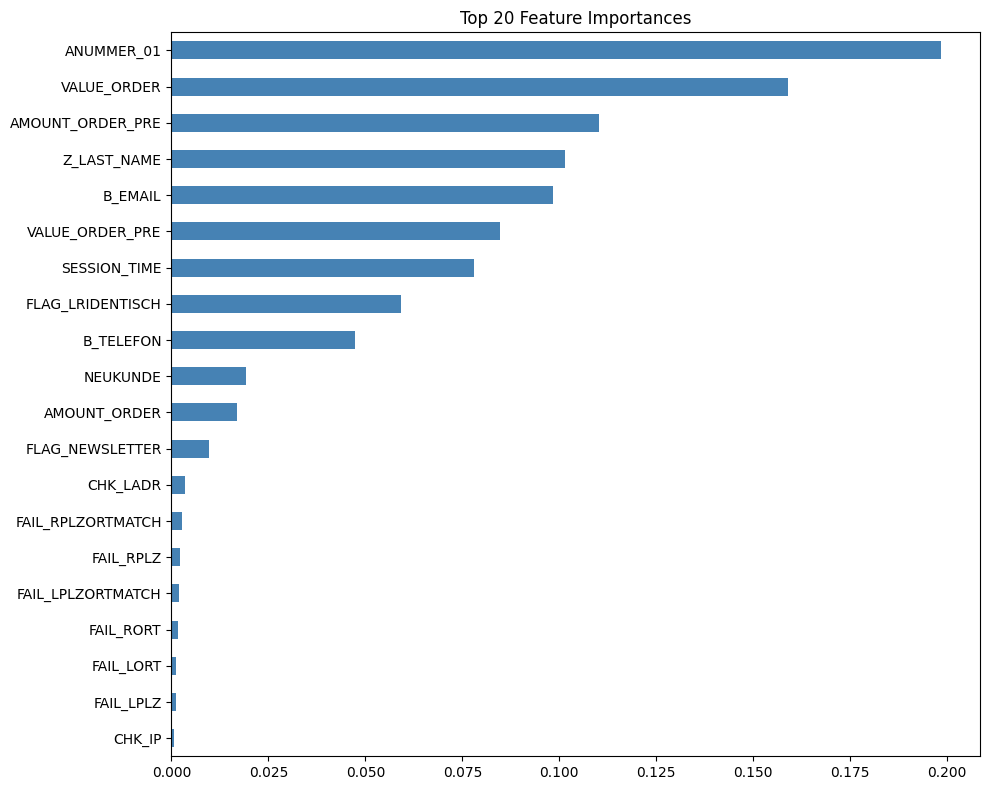

AUC-ROC: 0.649604071394418


In [32]:
# 4a — Classification reports:
# Training set performance
y_train_pred = final_model.predict(X_train_sm)
print('=== TRAINING SET ===')
print(classification_report(y_train_sm, y_train_pred, target_names=['no','yes']))
# Testing set performance  — this is the main result
y_test_pred = final_model.predict(X_test)
print('=== TEST SET ===')
print(classification_report(y_test, y_test_pred, target_names=['no','yes']))
# 4b — Confusion matrix heatmap:
import seaborn as sns
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no','yes'], yticklabels=['no','yes'])
plt.title('Confusion Matrix — Test Set')
plt.show()  # Right-click → Save image → paste into report
# 4c — ROC Curve:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title('ROC Curve — Test Set')  ;  plt.show()
# 4d — Feature importance plot:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns.tolist())
importances.nlargest(20).sort_values().plot(kind='barh', figsize=(10,8), color='steelblue')
plt.title('Top 20 Feature Importances')
plt.tight_layout()  ;  plt.show()
# 4e — AUC-ROC score:
print('AUC-ROC:', roc_auc_score(y_test, final_model.predict_proba(X_test)[:,1]))